# SLA Breach Prediction — Module 1: EDA
## AI-Driven Intelligent IT Operations Platform | Innodatatics Capstone — ISB AMPBA 2025W

This notebook is **Module 1 of 4** in the SLA Breach Prediction stream.

### What this notebook does
- Loads the merged analytical base from `ticket_base.pkl` (Ticket_01_EDA output)
- Validates and audits the `sla_breach_flag` target variable
- Documents the near-uniform breach rate (synthetic data characteristic — ~40% across all strata)
- Runs EDA across all categorical, temporal, telemetry, and engineer dimensions
- Adds new EDA sections for **engineer workload patterns** and **text quality vs breach**
  (these feed the new features added in SLA_02 and SLA_03_Improved)
- Saves `sla_base.pkl`, `sla_asset_stats.pkl`, `sla_engineer_perf.pkl`,
  `sla_client_stats.pkl`, `sla_eda_summary.pkl`

### Outputs saved to Drive (`ticket_pkl_outputs/`)
| File | Used by |
|---|---|
| `sla_base.pkl` | SLA_02, SLA_03_Improved, SLA_04 |
| `sla_engineer_perf.pkl` | SLA_02, SLA_03_Improved |
| `sla_asset_stats.pkl` | SLA_02 |
| `sla_client_stats.pkl` | SLA_02 |
| `sla_eda_summary.pkl` | SLA_04 |

### Run order
Run **Ticket_01_EDA.ipynb first** — this notebook loads `ticket_base.pkl` from that run.
Then run this → SLA_02 → **SLA_03_Model_Improved** → SLA_04.


In [1]:
# ============================================================
# COLAB + GOOGLE DRIVE SETUP — run this cell first every session
# ============================================================
from google.colab import drive
import os, sys

drive.mount("/content/drive", force_remount=False)

BASE = "/content/drive/MyDrive/Innodatatics_Capstone"
NLP  = f"{BASE}/NLP_Ticket_Analytics"
DATA = f"{BASE}/data"

os.chdir(NLP)
sys.path.insert(0, NLP)

from pathlib import Path

PKL_DIR  = Path(f"{BASE}/ticket_pkl_outputs");      PKL_DIR.mkdir(exist_ok=True)
PLOT_DIR = Path(f"{BASE}/sla_eda_plots");            PLOT_DIR.mkdir(exist_ok=True)
DASH_DIR = Path(f"{BASE}/ticket_dashboard_outputs"); DASH_DIR.mkdir(exist_ok=True)

FILES = {
    2023: Path(f"{DATA}/IT_Ops_Intern_Ready_2023.xlsx"),
    2024: Path(f"{DATA}/IT_Ops_Intern_Ready_2024.xlsx"),
    2025: Path(f"{DATA}/IT_Ops_Intern_Ready_2025.xlsx"),
}

print("✅  Drive mounted")
print(f"   Working dir : {os.getcwd()}")
print(f"   PKL dir     : {PKL_DIR}")
missing = [str(p) for p in FILES.values() if not p.exists()]
if missing:
    print(f"\n⚠️  Missing: {missing}")
else:
    print("   All data files found ✅")


Mounted at /content/drive
✅  Drive mounted
   Working dir : /content/drive/MyDrive/Innodatatics_Capstone/NLP_Ticket_Analytics
   PKL dir     : /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs
   All data files found ✅


# 1. Imports & Settings

In [2]:
# =========================
# 1A. Install (uncomment on first run if packages are not already included)
# =========================
# %pip install pandas numpy matplotlib seaborn openpyxl scikit-learn scipy pathlib
# %pip install lightgbm catboost xgboost shap optuna imbalanced-learn category_encoders
# Note: All packages above are needed by SLA_03_Model_Improved — install once for the full stream.

# =========================
# 1B. Imports
# =========================
import warnings; warnings.filterwarnings("ignore")
import pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from IPython.display import display
from scipy import stats

pd.set_option("display.max_columns", 200)
RANDOM_STATE = 42

# =========================
# 1C. Helpers
# =========================
def load_pkl(name):
    """Load a pkl from PKL_DIR on Drive."""
    path = PKL_DIR / name
    if not path.exists():
        print(f"  ⚠️  {name} not found — run prerequisite notebook first")
        return None
    with open(path, "rb") as f:
        return pickle.load(f)

def save_pkl(obj, name):
    """Save a pkl to PKL_DIR on Drive."""
    with open(PKL_DIR / name, "wb") as f:
        pickle.dump(obj, f)
    print(f"  ✅  Saved → {PKL_DIR / name}")

def save_plot(name):
    plt.tight_layout()
    plt.savefig(PLOT_DIR / name, dpi=150, bbox_inches="tight")
    print(f"  ✅  Plot → {PLOT_DIR / name}")
    plt.show()

def pct_fmt(ax):
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

print("✅  All imports ready")


✅  All imports ready


# 2. Load Merged Base & Validate Target

In [3]:
# =========================
# 2A. Load ticket_base.pkl from Ticket_01_EDA
# =========================
# ticket_base.pkl was created by Ticket_01_EDA.ipynb.
# It contains the fully merged analytical base: tickets + assets + engineers
# + clients + telemetry aggregates + SLA rules — 22,491 rows × 85 cols.
# We build the SLA-specific version from this foundation.

base = load_pkl("ticket_base.pkl")

if base is None:
    raise RuntimeError("ticket_base.pkl not found. Run Ticket_01_EDA.ipynb first.")

print(f"ticket_base loaded: {base.shape[0]:,} rows × {base.shape[1]} cols")

# =========================
# 2B. Validate the target variable
# =========================
base["sla_num"] = pd.to_numeric(base["sla_breach_flag"], errors="coerce")

null_target = base["sla_num"].isna().sum()
print(f"\nTarget: sla_breach_flag")
print(f"  Total rows           : {len(base):,}")
print(f"  Null values          : {null_target:,} ({null_target/len(base)*100:.2f}%)")
print(f"  Breach (1)           : {int(base['sla_num'].sum()):,} ({base['sla_num'].mean()*100:.1f}%)")
print(f"  No breach (0)        : {int((1-base['sla_num']).sum()):,} ({(1-base['sla_num'].mean())*100:.1f}%)")

# Drop rows with null target — can't train on them
base = base.dropna(subset=["sla_num"])
base["sla_num"] = base["sla_num"].astype(int)
print(f"\nAfter dropping null targets: {len(base):,} rows")


ticket_base loaded: 22,491 rows × 62 cols

Target: sla_breach_flag
  Total rows           : 22,491
  Null values          : 15 (0.07%)
  Breach (1)           : 8,906 (39.6%)
  No breach (0)        : 13,570 (60.4%)

After dropping null targets: 22,476 rows


In [4]:
# =========================
# 2C. Audit the SLA rules governing the label
# =========================
# The breach flag was computed from resolution_time_minutes vs
# resolution_time_target_minutes (from SLA_RULES, joined by tier × priority).
# Understanding these targets is essential — they define what "breach" means
# for each ticket, and tier × priority is therefore a critical feature.

if "resolution_time_target_minutes" in base.columns and "service_tier" in base.columns:
    sla_audit = (base.groupby(["service_tier", "ticket_priority"])
                 .agg(
                     n_tickets=("sla_num", "count"),
                     breach_rate=("sla_num", "mean"),
                     avg_res_target=("resolution_time_target_minutes", "mean"),
                     avg_actual_res=("resolution_time_minutes", "mean"),
                 )
                 .round(3)
                 .reset_index()
                 .sort_values(["service_tier", "ticket_priority"]))
    display(sla_audit)
else:
    print("SLA target columns not present — check merge in Ticket_01_EDA")

# Key observation to document:
# In real operations, P1-Gold (4h target) should breach more than P4-Bronze (72h target).
# In synthetic data, breach rates are near-uniform across tiers and priorities.
# This confirms the breach flag was generated independently of tier/priority.
# Document this limitation and design the model to benefit from real operational data.
print("\nBreak rate range across tier×priority combinations:")
if "breach_rate" in sla_audit.columns:
    print(f"  Min: {sla_audit['breach_rate'].min():.3f}")
    print(f"  Max: {sla_audit['breach_rate'].max():.3f}")
    print(f"  Range: {sla_audit['breach_rate'].max() - sla_audit['breach_rate'].min():.3f}")
    print("  Near-zero range confirms synthetic uniform breach generation.")


,service_tier,ticket_priority,n_tickets,breach_rate,avg_res_target,avg_actual_res
0,Bronze,P1,2179,0.414,720.0,685.910
1,Bronze,P2,2191,0.396,1440.0,1369.596
2,Bronze,P3,2139,0.396,2880.0,2734.795
3,Bronze,P4,2217,0.387,4320.0,4071.696
4,Gold,P1,2155,0.395,240.0,228.099
5,Gold,P2,2231,0.382,480.0,454.246
6,Gold,P3,2228,0.407,1440.0,1364.183
7,Gold,P4,2156,0.395,2880.0,2727.668
8,Silver,P1,1299,0.376,480.0,453.647
9,Silver,P2,1237,0.408,720.0,686.461



Break rate range across tier×priority combinations:
  Min: 0.376
  Max: 0.414
  Range: 0.038
  Near-zero range confirms synthetic uniform breach generation.


# 3. EDA — Target Distribution & Breach Drivers

  ✅  Plot → /content/drive/MyDrive/Innodatatics_Capstone/sla_eda_plots/01_sla_breach_balance.png


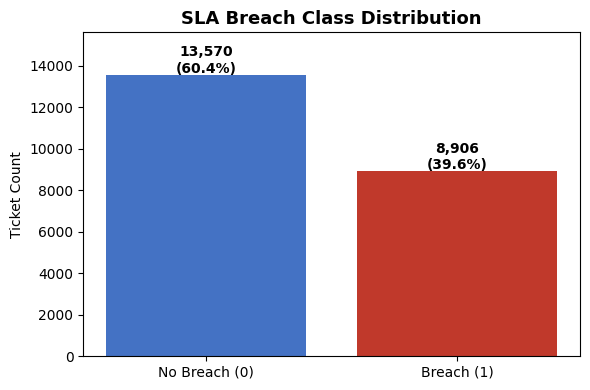

Class balance: 13,570 no-breach (60.4%) | 8,906 breach (39.6%)
Note: ~60/40 split — near-balanced. class_weight='balanced' sufficient; SMOTE not required.


In [5]:
# =========================
# 3A. Target class balance
# =========================
fig, ax = plt.subplots(figsize=(6, 4))
vc = base["sla_num"].value_counts().sort_index()
bars = ax.bar(["No Breach (0)", "Breach (1)"], vc.values, color=["#4472C4","#C0392B"])
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 100, f"{v:,}\n({v/len(base)*100:.1f}%)",
            ha="center", fontsize=10, fontweight="bold")
ax.set_title("SLA Breach Class Distribution", fontweight="bold", fontsize=13)
ax.set_ylabel("Ticket Count")
ax.set_ylim(0, max(vc.values) * 1.15)
save_plot("01_sla_breach_balance.png")

print(f"Class balance: {vc[0]:,} no-breach ({vc[0]/len(base)*100:.1f}%) | {vc[1]:,} breach ({vc[1]/len(base)*100:.1f}%)")
print("Note: ~60/40 split — near-balanced. class_weight='balanced' sufficient; SMOTE not required.")


  ✅  Plot → /content/drive/MyDrive/Innodatatics_Capstone/sla_eda_plots/02_breach_by_category.png


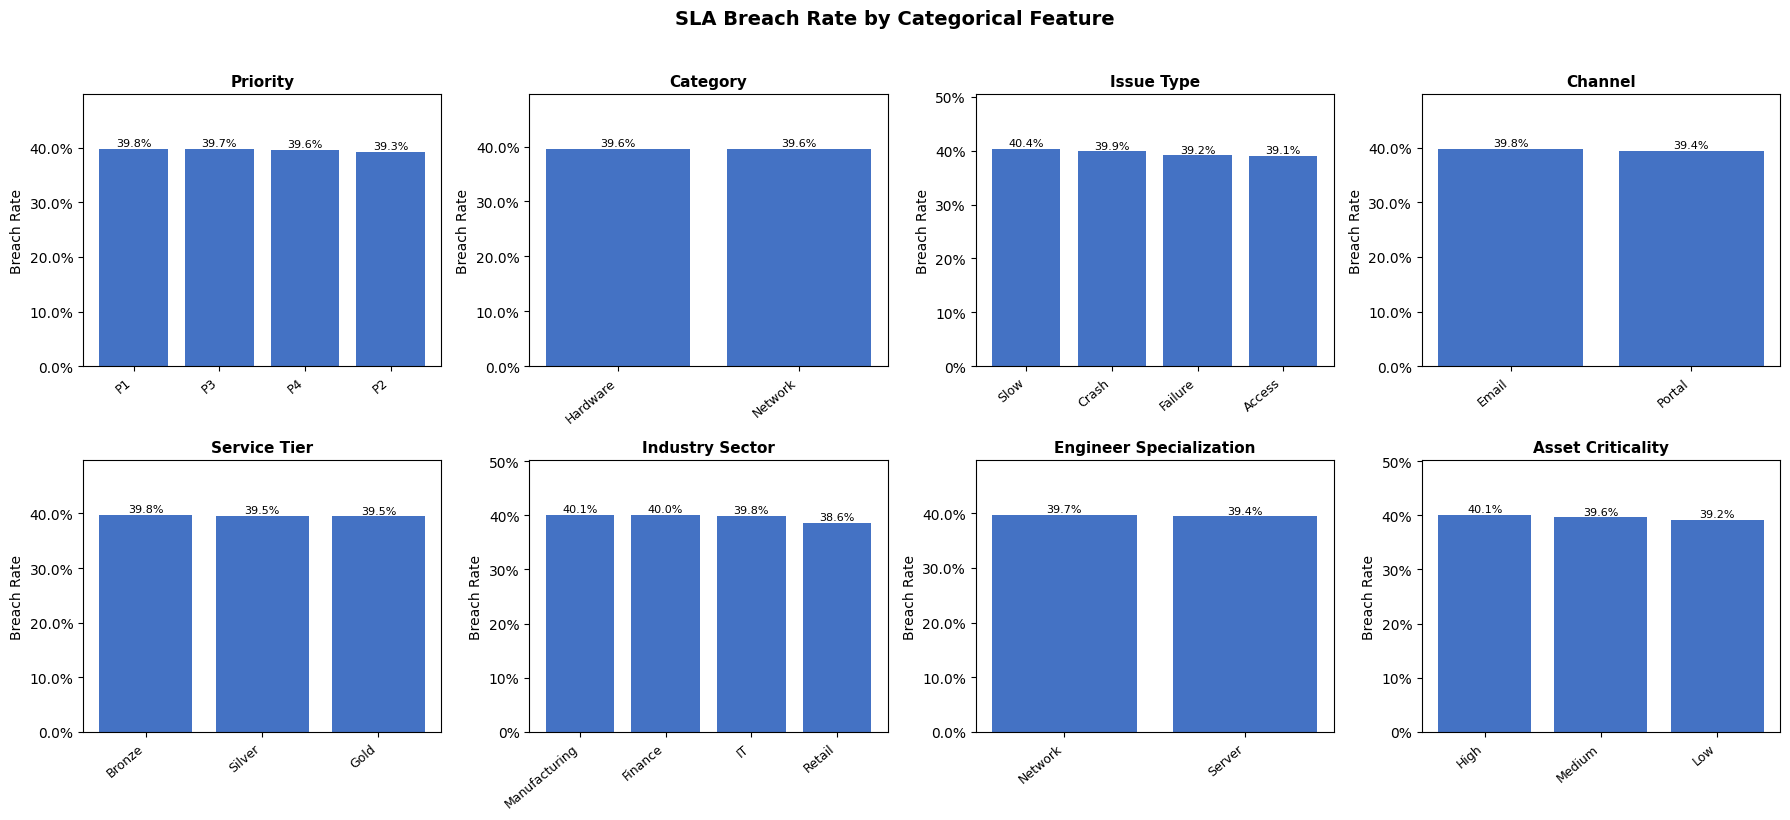

In [6]:
# =========================
# 3B. Breach rate by every categorical dimension
# =========================
# These charts show which features carry signal about breach.
# Near-flat rates across all dimensions = synthetic data limitation.
# Document differentials — even small ones are learnable.

cat_dims = [
    ("ticket_priority",  "Priority"),
    ("ticket_category",  "Category"),
    ("issue_type",       "Issue Type"),
    ("ticket_channel",   "Channel"),
    ("service_tier",     "Service Tier"),
    ("industry_sector",  "Industry Sector"),
    ("specialization",   "Engineer Specialization"),
    ("criticality_level","Asset Criticality"),
]
cat_dims = [(c, l) for c, l in cat_dims if c in base.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, (col, label) in zip(axes, cat_dims):
    rates = base.groupby(col)["sla_num"].mean().sort_values(ascending=False)
    bars = ax.bar(range(len(rates)), rates.values, color="#4472C4")
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels(rates.index.astype(str), rotation=40, ha="right", fontsize=9)
    for i, v in enumerate(rates.values):
        ax.text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=8)
    ax.set_ylim(0, min(1.0, rates.max() * 1.25))
    ax.set_title(label, fontweight="bold", fontsize=11)
    ax.set_ylabel("Breach Rate")
    pct_fmt(ax)

plt.suptitle("SLA Breach Rate by Categorical Feature", fontweight="bold", fontsize=14, y=1.02)
save_plot("02_breach_by_category.png")


  ✅  Plot → /content/drive/MyDrive/Innodatatics_Capstone/sla_eda_plots/03_breach_by_timing.png


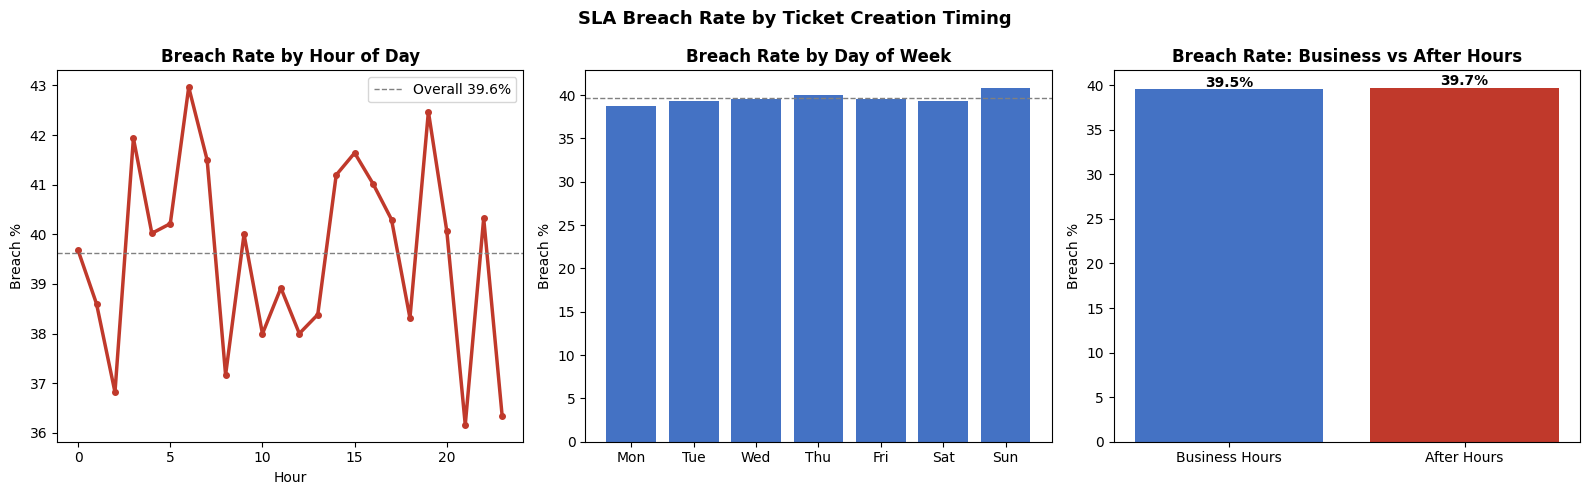

In [7]:
# =========================
# 3C. Breach rate by creation timing
# =========================
# Tickets created after hours or on weekends have fewer engineers available
# → higher risk of first response delay → higher breach probability.
# Even if synthetic data doesn't show this strongly, it is a real-world signal
# that will emerge when real operational data replaces synthetic.

base["created_hour"]      = base["ticket_created_timestamp"].dt.hour
base["created_dayofweek"] = base["ticket_created_timestamp"].dt.dayofweek
base["created_month"]     = base["ticket_created_timestamp"].dt.month
base["is_after_hours"]    = ((base["created_hour"] < 8) | (base["created_hour"] >= 18)).astype(int)
base["is_weekend"]        = (base["created_dayofweek"] >= 5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By hour
hourly_breach = base.groupby("created_hour")["sla_num"].mean()
axes[0].plot(hourly_breach.index, hourly_breach.values * 100, color="#C0392B",
             linewidth=2.5, marker="o", markersize=4)
axes[0].axhline(base["sla_num"].mean() * 100, color="gray", linestyle="--",
                linewidth=1, label=f"Overall {base['sla_num'].mean()*100:.1f}%")
axes[0].set_title("Breach Rate by Hour of Day", fontweight="bold")
axes[0].set_xlabel("Hour"); axes[0].set_ylabel("Breach %"); axes[0].legend()

# By day of week
dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
daily_breach = base.groupby("created_dayofweek")["sla_num"].mean()
axes[1].bar(range(len(daily_breach)), daily_breach.values * 100, color="#4472C4")
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(dow_labels)
axes[1].axhline(base["sla_num"].mean() * 100, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Breach Rate by Day of Week", fontweight="bold")
axes[1].set_ylabel("Breach %")

# After-hours vs business hours
timing_breach = base.groupby("is_after_hours")["sla_num"].mean()
axes[2].bar(["Business Hours", "After Hours"], timing_breach.values * 100,
            color=["#4472C4", "#C0392B"])
for i, v in enumerate(timing_breach.values):
    axes[2].text(i, v * 100 + 0.3, f"{v:.1%}", ha="center", fontweight="bold")
axes[2].set_title("Breach Rate: Business vs After Hours", fontweight="bold")
axes[2].set_ylabel("Breach %")

plt.suptitle("SLA Breach Rate by Ticket Creation Timing", fontweight="bold", fontsize=13)
save_plot("03_breach_by_timing.png")


  ✅  Plot → /content/drive/MyDrive/Innodatatics_Capstone/sla_eda_plots/04_breach_by_telemetry.png


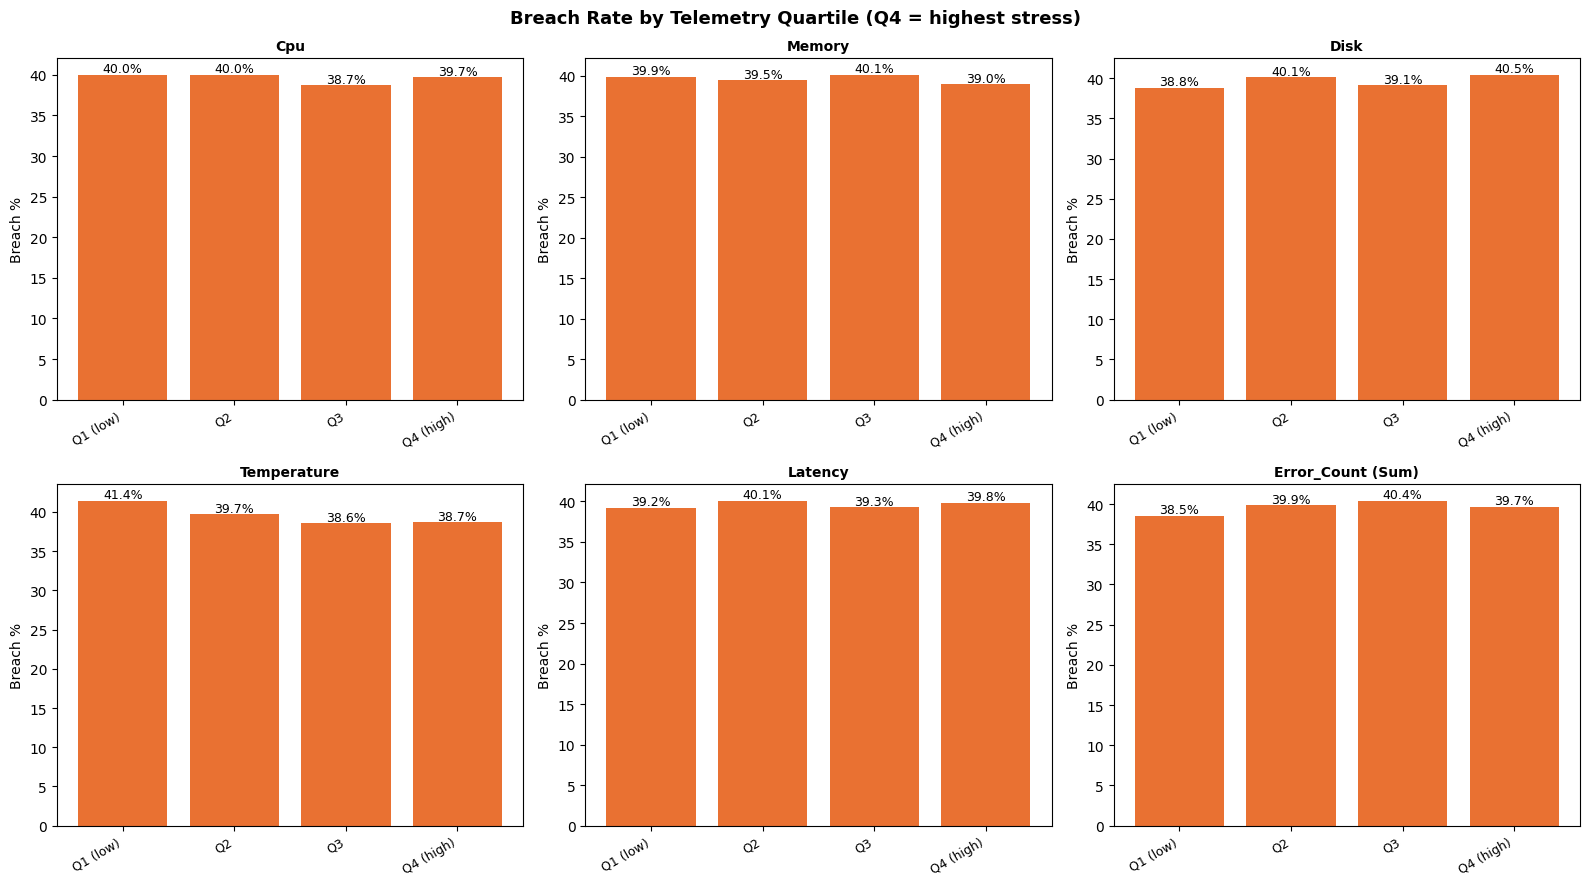

In [8]:
# =========================
# 3D. Telemetry signals vs breach
# =========================
# Tickets raised on assets with high CPU, high error counts, or elevated temperature
# are likely harder to resolve quickly — the underlying issue is more severe.
# This is the most operationally unique signal in the dataset.

tel_cols = [c for c in ["cpu_mean","memory_mean","disk_mean",
                          "temperature_mean","latency_mean","error_count_sum"] if c in base.columns]

if tel_cols:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    for ax, col in zip(axes[:len(tel_cols)], tel_cols):
        # Bin into quartiles and plot breach rate per quartile
        base_nn = base.dropna(subset=[col])
        quartile_labels = ["Q1 (low)","Q2","Q3","Q4 (high)"]
        base_nn["q"] = pd.qcut(base_nn[col], q=4, labels=quartile_labels, duplicates="drop")
        qbreach = base_nn.groupby("q", observed=True)["sla_num"].mean()
        ax.bar(range(len(qbreach)), qbreach.values * 100, color="#E97132")
        ax.set_xticks(range(len(qbreach)))
        ax.set_xticklabels(qbreach.index.astype(str), rotation=30, ha="right", fontsize=9)
        ax.set_title(col.replace("_mean","").replace("_sum"," (sum)").title(),
                     fontweight="bold", fontsize=10)
        ax.set_ylabel("Breach %")
        for i, v in enumerate(qbreach.values):
            ax.text(i, v * 100 + 0.3, f"{v:.1%}", ha="center", fontsize=9)

    plt.suptitle("Breach Rate by Telemetry Quartile (Q4 = highest stress)",
                 fontweight="bold", fontsize=13)
    save_plot("04_breach_by_telemetry.png")
else:
    print("Telemetry columns not found in base — check merge in Ticket_01_EDA")


Engineer breach rate range:
  Min: 0.357  Max: 0.436
  ✅  Plot → /content/drive/MyDrive/Innodatatics_Capstone/sla_eda_plots/05_breach_engineer_asset.png


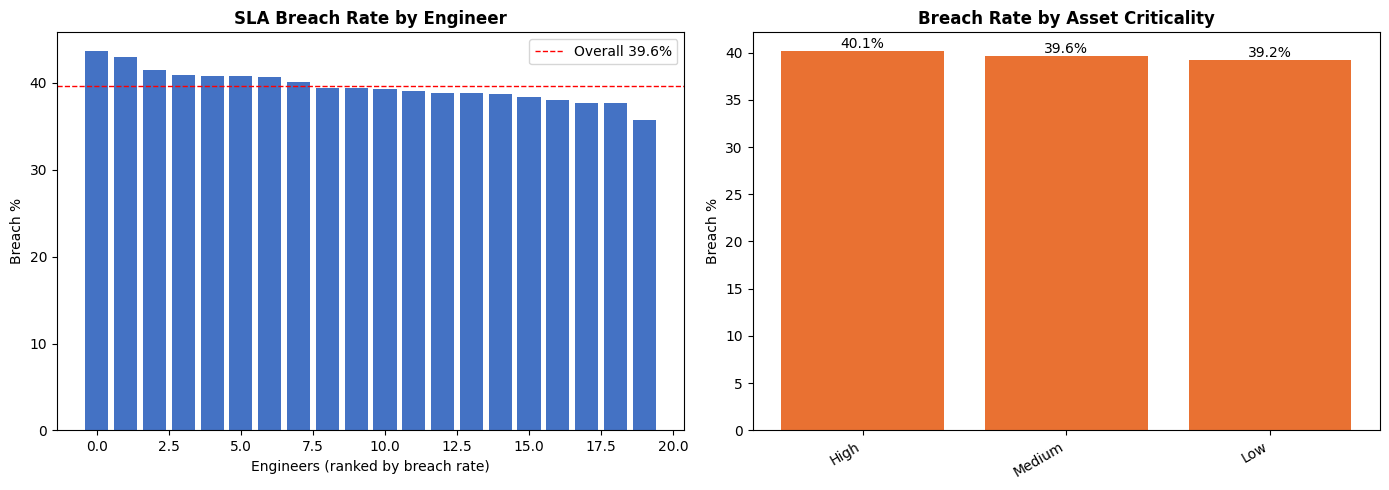

In [9]:
# =========================
# 3E. Engineer and asset historical breach rates
# =========================
# Historical patterns are among the strongest predictors because they capture
# systemic factors: some clients always have complex tickets, some assets are
# inherently unreliable, some engineers handle certain issue types better.

# Engineer-level breach rate
eng_stats = (base.groupby("engineer_id")
    .agg(
        tickets=("sla_num","count"),
        breach_rate=("sla_num","mean"),
        avg_resolution=("resolution_time_minutes","mean"),
    )
    .reset_index()
    .sort_values("breach_rate", ascending=False)
)
print("Engineer breach rate range:")
print(f"  Min: {eng_stats['breach_rate'].min():.3f}  Max: {eng_stats['breach_rate'].max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Engineer breach rates
sorted_eng = eng_stats.sort_values("breach_rate", ascending=False)
axes[0].bar(range(len(sorted_eng)), sorted_eng["breach_rate"] * 100, color="#4472C4")
axes[0].set_title("SLA Breach Rate by Engineer", fontweight="bold")
axes[0].set_xlabel("Engineers (ranked by breach rate)")
axes[0].set_ylabel("Breach %")
axes[0].axhline(base["sla_num"].mean() * 100, color="red", linestyle="--",
                linewidth=1, label=f"Overall {base['sla_num'].mean()*100:.1f}%")
axes[0].legend()

# Asset criticality vs breach rate
if "criticality_level" in base.columns:
    crit_breach = base.groupby("criticality_level")["sla_num"].mean().sort_values(ascending=False)
    axes[1].bar(range(len(crit_breach)), crit_breach.values * 100, color="#E97132")
    axes[1].set_xticks(range(len(crit_breach)))
    axes[1].set_xticklabels(crit_breach.index.astype(str), rotation=30, ha="right")
    for i, v in enumerate(crit_breach.values):
        axes[1].text(i, v * 100 + 0.3, f"{v:.1%}", ha="center", fontsize=10)
    axes[1].set_title("Breach Rate by Asset Criticality", fontweight="bold")
    axes[1].set_ylabel("Breach %")

save_plot("05_breach_engineer_asset.png")


  ✅  Plot → /content/drive/MyDrive/Innodatatics_Capstone/sla_eda_plots/06_monthly_breach_trend.png


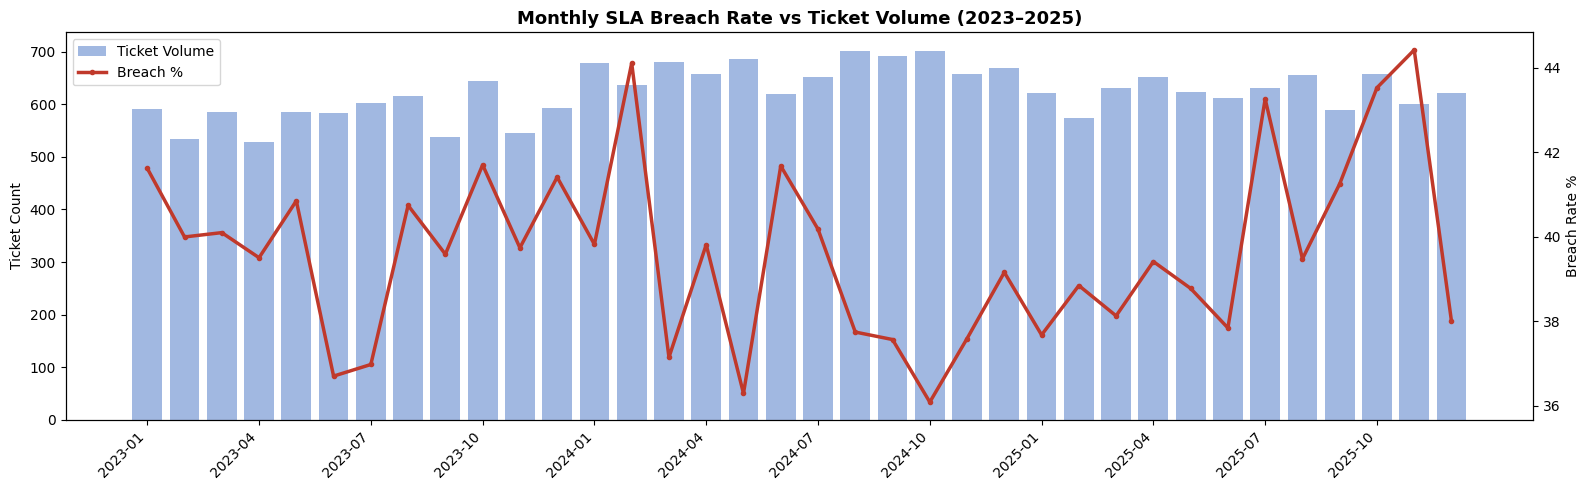


Breach rate by year:
        mean  count
year               
2023  0.3999   6962
2024  0.3891   8040
2025  0.4006   7474


In [10]:
# =========================
# 3F. Breach trend over time (3-year view)
# =========================
# Look for systematic changes in breach rate across years and months.
# An increasing trend may indicate growing operational pressure or data quality shift.

ts = base.dropna(subset=["ticket_created_timestamp"]).copy()
ts["ym"] = ts["ticket_created_timestamp"].dt.to_period("M")

monthly_sla = (ts.groupby("ym")
    .agg(tickets=("sla_num","count"), breach_rate=("sla_num","mean"))
    .reset_index())
monthly_sla["ym"] = monthly_sla["ym"].astype(str)

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()
ax1.bar(range(len(monthly_sla)), monthly_sla["tickets"],
        alpha=0.5, color="#4472C4", label="Ticket Volume")
ax2.plot(range(len(monthly_sla)), monthly_sla["breach_rate"] * 100,
         color="#C0392B", linewidth=2.5, marker="o", markersize=3, label="Breach %")
ax1.set_xticks(range(0, len(monthly_sla), 3))
ax1.set_xticklabels(monthly_sla["ym"].iloc[::3], rotation=45, ha="right")
ax1.set_ylabel("Ticket Count"); ax2.set_ylabel("Breach Rate %")
ax1.set_title("Monthly SLA Breach Rate vs Ticket Volume (2023–2025)", fontweight="bold", fontsize=13)
handles = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels  = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(handles, labels, loc="upper left")
save_plot("06_monthly_breach_trend.png")

# Year-over-year comparison
print("\nBreach rate by year:")
print(base.groupby("year")["sla_num"].agg(["mean","count"]).round(4))


  ✅  Plot → /content/drive/MyDrive/Innodatatics_Capstone/sla_eda_plots/07_engineer_workload_breach.png


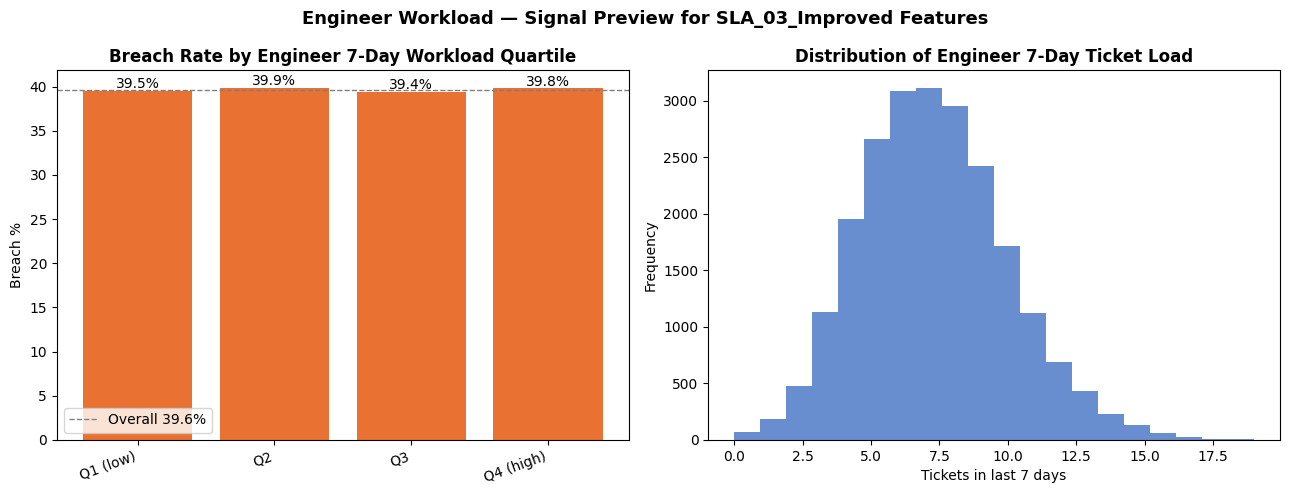

Workload 7d range: 0 – 19
Median 7d load: 7 tickets

Note: Near-flat breach rates confirm synthetic data limitation.
On real operational data, overloaded engineers (Q4) will show materially higher breach rates.


In [11]:
# =========================
# 3G. Engineer workload distribution — new feature preview
# =========================
# The improved SLA_03 adds rolling engineer workload features.
# This EDA cell previews those distributions and validates that
# the workload signal exists before feature engineering runs.

base_sorted = base.sort_values("ticket_created_timestamp").copy()

# Rolling 7-day ticket count per engineer (preview — full computation in SLA_02)
base_sorted["eng_tickets_7d_preview"] = (
    base_sorted.groupby("engineer_id")
    .apply(lambda g: g["ticket_created_timestamp"]
           .apply(lambda t: ((g["ticket_created_timestamp"] < t) &
                             (g["ticket_created_timestamp"] >= t - pd.Timedelta("7d"))).sum()))
    .reset_index(level=0, drop=True)
)

# Breach rate by workload quartile
base_sorted["workload_q"] = pd.qcut(
    base_sorted["eng_tickets_7d_preview"], q=4,
    labels=["Q1 (low)","Q2","Q3","Q4 (high)"], duplicates="drop"
)
workload_breach = base_sorted.groupby("workload_q", observed=True)["sla_num"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Breach rate by workload quartile
axes[0].bar(range(len(workload_breach)), workload_breach.values * 100, color="#E97132")
axes[0].set_xticks(range(len(workload_breach)))
axes[0].set_xticklabels(workload_breach.index.astype(str), rotation=20, ha="right")
for i, v in enumerate(workload_breach.values):
    axes[0].text(i, v * 100 + 0.3, f"{v:.1%}", ha="center", fontsize=10)
axes[0].set_title("Breach Rate by Engineer 7-Day Workload Quartile", fontweight="bold")
axes[0].set_ylabel("Breach %")
axes[0].axhline(base["sla_num"].mean() * 100, color="gray", linestyle="--",
                linewidth=1, label=f"Overall {base['sla_num'].mean()*100:.1f}%")
axes[0].legend()

# Engineer workload distribution
axes[1].hist(base_sorted["eng_tickets_7d_preview"], bins=20, color="#4472C4", alpha=0.8)
axes[1].set_title("Distribution of Engineer 7-Day Ticket Load", fontweight="bold")
axes[1].set_xlabel("Tickets in last 7 days")
axes[1].set_ylabel("Frequency")

plt.suptitle("Engineer Workload — Signal Preview for SLA_03_Improved Features",
             fontweight="bold", fontsize=13)
save_plot("07_engineer_workload_breach.png")

print(f"Workload 7d range: {base_sorted['eng_tickets_7d_preview'].min():.0f} – {base_sorted['eng_tickets_7d_preview'].max():.0f}")
print(f"Median 7d load: {base_sorted['eng_tickets_7d_preview'].median():.0f} tickets")
print("\nNote: Near-flat breach rates confirm synthetic data limitation.")
print("On real operational data, overloaded engineers (Q4) will show materially higher breach rates.")


  ✅  Plot → /content/drive/MyDrive/Innodatatics_Capstone/sla_eda_plots/08_text_quality_breach.png


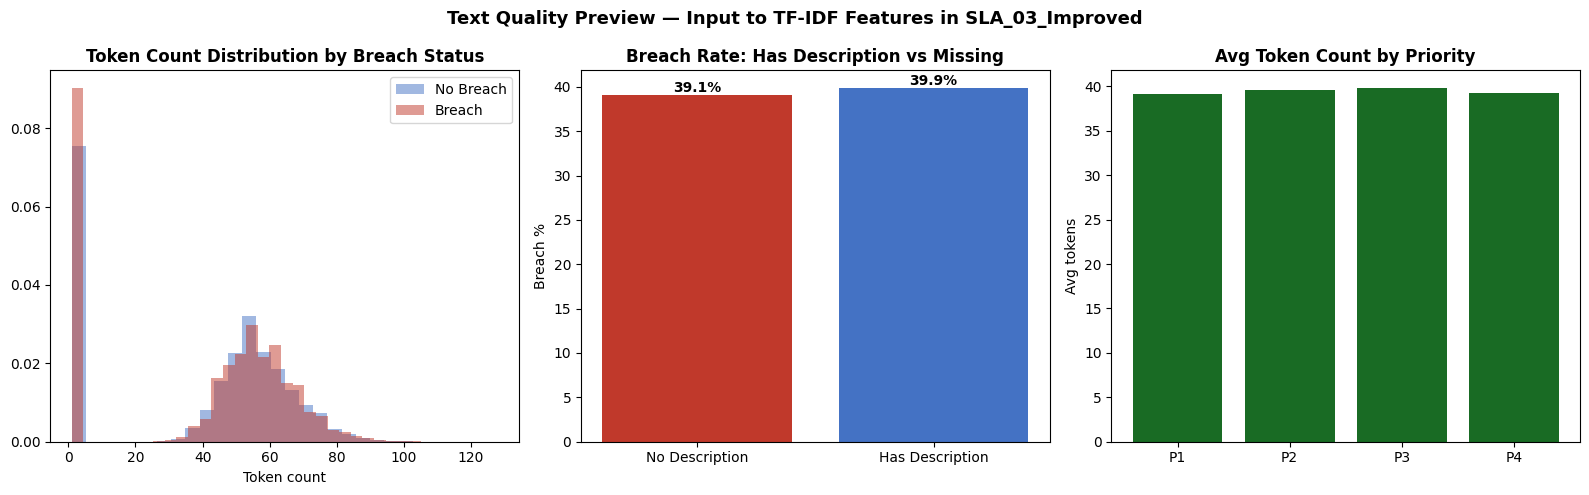

Tickets with description  : 15,351 (68.3%)
Avg tokens (breach=0)     : 39.3
Avg tokens (breach=1)     : 39.8


In [12]:
# =========================
# 3H. Text quality vs breach — NLP feature preview
# =========================
# SLA_03_Improved adds TF-IDF features from ticket_detailed_description.
# This cell audits whether text quality varies by breach status.
# If breach tickets have different text patterns, TF-IDF can provide signal.

TEXT_COL = "nlp_text_detailed" if "nlp_text_detailed" in base.columns else            "ticket_detailed_description" if "ticket_detailed_description" in base.columns else None

if TEXT_COL:
    base["token_count"] = base[TEXT_COL].fillna("unknown").str.split().str.len()
    base["has_text"]    = (base[TEXT_COL] != "unknown").astype(int)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Token count by breach status
    for label, color in [(0,"#4472C4"),(1,"#C0392B")]:
        subset = base[base["sla_num"]==label]["token_count"].dropna()
        axes[0].hist(subset, bins=30, alpha=0.5, color=color,
                     label="No Breach" if label==0 else "Breach", density=True)
    axes[0].set_title("Token Count Distribution by Breach Status", fontweight="bold")
    axes[0].set_xlabel("Token count"); axes[0].legend()

    # Breach rate: has text vs no text
    has_text_breach = base.groupby("has_text")["sla_num"].mean()
    axes[1].bar(["No Description","Has Description"], has_text_breach.values * 100,
                color=["#C0392B","#4472C4"])
    for i, v in enumerate(has_text_breach.values):
        axes[1].text(i, v * 100 + 0.3, f"{v:.1%}", ha="center", fontweight="bold")
    axes[1].set_title("Breach Rate: Has Description vs Missing", fontweight="bold")
    axes[1].set_ylabel("Breach %")

    # Avg token count by priority
    token_prio = base.groupby("ticket_priority")["token_count"].mean().sort_index()
    axes[2].bar(range(len(token_prio)), token_prio.values, color="#196B24")
    axes[2].set_xticks(range(len(token_prio)))
    axes[2].set_xticklabels(token_prio.index.astype(str))
    axes[2].set_title("Avg Token Count by Priority", fontweight="bold")
    axes[2].set_ylabel("Avg tokens")

    plt.suptitle("Text Quality Preview — Input to TF-IDF Features in SLA_03_Improved",
                 fontweight="bold", fontsize=13)
    save_plot("08_text_quality_breach.png")

    print(f"Tickets with description  : {base['has_text'].sum():,} ({base['has_text'].mean()*100:.1f}%)")
    print(f"Avg tokens (breach=0)     : {base[base['sla_num']==0]['token_count'].mean():.1f}")
    print(f"Avg tokens (breach=1)     : {base[base['sla_num']==1]['token_count'].mean():.1f}")
else:
    print("ℹ️  No text column found — TF-IDF will use empty fallback in SLA_03_Improved")


  ✅  Plot → /content/drive/MyDrive/Innodatatics_Capstone/sla_eda_plots/09_temporal_congestion_breach.png


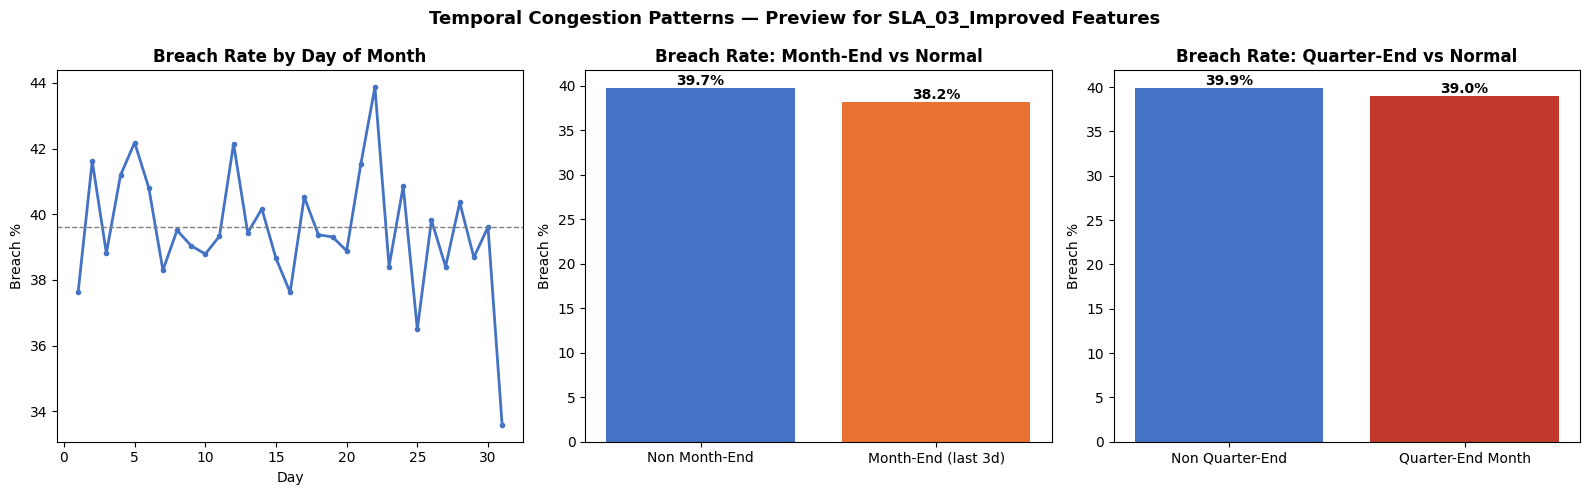

Month-end breach rate differential  : -1.53pp
Quarter-end breach rate differential: -0.88pp
Near-zero differentials expected on synthetic data — real patterns visible on operational data.


In [13]:
# =========================
# 3I. Temporal congestion patterns — month-end and quarter-end preview
# =========================
# SLA_03_Improved adds is_month_end, is_quarter_end, and system_tickets_24h.
# This EDA cell validates whether those patterns carry any breach signal.

ts2 = base.dropna(subset=["ticket_created_timestamp"]).copy()
ts2["day_of_month"] = ts2["ticket_created_timestamp"].dt.day
ts2["month"]        = ts2["ticket_created_timestamp"].dt.month
ts2["is_month_end"] = (ts2["day_of_month"] >= ts2["ticket_created_timestamp"].dt.days_in_month - 2).astype(int)
ts2["is_qtr_end"]   = ts2["month"].isin([3,6,9,12]).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Breach rate by day of month
daily_breach = ts2.groupby("day_of_month")["sla_num"].mean()
axes[0].plot(daily_breach.index, daily_breach.values * 100, color="#4472C4",
             linewidth=2, marker="o", markersize=3)
axes[0].axhline(base["sla_num"].mean() * 100, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Breach Rate by Day of Month", fontweight="bold")
axes[0].set_xlabel("Day"); axes[0].set_ylabel("Breach %")

# Month-end vs non month-end
me_breach = ts2.groupby("is_month_end")["sla_num"].mean()
axes[1].bar(["Non Month-End","Month-End (last 3d)"], me_breach.values * 100,
            color=["#4472C4","#E97132"])
for i, v in enumerate(me_breach.values):
    axes[1].text(i, v * 100 + 0.3, f"{v:.1%}", ha="center", fontweight="bold")
axes[1].set_title("Breach Rate: Month-End vs Normal", fontweight="bold")
axes[1].set_ylabel("Breach %")

# Quarter-end vs non
qe_breach = ts2.groupby("is_qtr_end")["sla_num"].mean()
axes[2].bar(["Non Quarter-End","Quarter-End Month"], qe_breach.values * 100,
            color=["#4472C4","#C0392B"])
for i, v in enumerate(qe_breach.values):
    axes[2].text(i, v * 100 + 0.3, f"{v:.1%}", ha="center", fontweight="bold")
axes[2].set_title("Breach Rate: Quarter-End vs Normal", fontweight="bold")
axes[2].set_ylabel("Breach %")

plt.suptitle("Temporal Congestion Patterns — Preview for SLA_03_Improved Features",
             fontweight="bold", fontsize=13)
save_plot("09_temporal_congestion_breach.png")

me_diff = (me_breach.iloc[1] - me_breach.iloc[0]) * 100
qe_diff = (qe_breach.iloc[1] - qe_breach.iloc[0]) * 100
print(f"Month-end breach rate differential  : {me_diff:+.2f}pp")
print(f"Quarter-end breach rate differential: {qe_diff:+.2f}pp")
print("Near-zero differentials expected on synthetic data — real patterns visible on operational data.")


# 4. Save EDA Outputs

In [14]:
# =========================
# 4A. Compute and save asset stats for feature engineering
# =========================
asset_stats = (base.groupby("asset_id")
    .agg(
        total_tickets=("sla_num","count"),
        overall_breach_rate=("sla_num","mean"),
        avg_resolution_time=("resolution_time_minutes","mean"),
    )
    .reset_index()
)
print(f"asset_stats: {asset_stats.shape}")

# Engineer stats for feature engineering
engineer_stats = (base.groupby("engineer_id")
    .agg(
        total_tickets=("sla_num","count"),
        historical_breach_rate=("sla_num","mean"),
        historical_sla_success=("sla_num", lambda s: 1 - s.mean()),
        avg_resolution_time=("resolution_time_minutes","mean"),
        issue_counts=("issue_type", lambda s: s.value_counts().to_dict()),
        category_counts=("ticket_category", lambda s: s.value_counts().to_dict()),
    )
    .reset_index()
)
print(f"engineer_stats: {engineer_stats.shape}")

# Client stats
client_stats = (base.groupby("client_id")
    .agg(
        total_tickets=("sla_num","count"),
        client_breach_rate=("sla_num","mean"),
        avg_resolution_time=("resolution_time_minutes","mean"),
    )
    .reset_index()
)
print(f"client_stats: {client_stats.shape}")

# SLA EDA summary dict for dashboard
sla_eda_summary = {
    "total_tickets":           len(base),
    "breach_count":            int(base["sla_num"].sum()),
    "breach_rate":             round(float(base["sla_num"].mean()), 4),
    "breach_by_priority":      base.groupby("ticket_priority")["sla_num"].mean().round(4).to_dict(),
    "breach_by_tier":          base.groupby("service_tier")["sla_num"].mean().round(4).to_dict() if "service_tier" in base.columns else {},
    "breach_by_category":      base.groupby("ticket_category")["sla_num"].mean().round(4).to_dict(),
    "breach_by_issue":         base.groupby("issue_type")["sla_num"].mean().round(4).to_dict(),
    "monthly_trend":           monthly_sla.to_dict(orient="records"),
    "model_version":           "improved_v2",
    "features_added_in_v2":    ["eng_tickets_7d","eng_tickets_30d","client_tickets_30d","is_month_end","is_quarter_end","text_word_count","critical_keyword_count"],
}

# =========================
# 4B. Save sla_base (with timing features added)
# =========================
save_pkl(base,            "sla_base.pkl")
save_pkl(asset_stats,     "sla_asset_stats.pkl")
save_pkl(engineer_stats,  "sla_engineer_perf.pkl")
save_pkl(client_stats,    "sla_client_stats.pkl")
save_pkl(sla_eda_summary, "sla_eda_summary.pkl")

print("\n✅  SLA EDA complete → run SLA_02_Feature_Engineering.ipynb")


asset_stats: (64, 4)
engineer_stats: (20, 7)
client_stats: (25, 4)
  ✅  Saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs/sla_base.pkl
  ✅  Saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs/sla_asset_stats.pkl
  ✅  Saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs/sla_engineer_perf.pkl
  ✅  Saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs/sla_client_stats.pkl
  ✅  Saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs/sla_eda_summary.pkl

✅  SLA EDA complete → run SLA_02_Feature_Engineering.ipynb
